# Projected births plot

### Author: Tihana Gray

In [9]:
# Imports & config
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("..") / ".." / "data" / "projectedbirths-cso.csv"

print("Looking for file at:", DATA_PATH.resolve())

Looking for file at: C:\Users\tihan\OneDrive\Desktop\ATU\programming-for-data-analytics\data\projectedbirths-cso.csv


In [10]:
# Load data
if not DATA_PATH.exists():
    raise FileNotFoundError(f"❌ File not found: {DATA_PATH.resolve()}")

df_raw = pd.read_csv(DATA_PATH)
df_raw.head()


,Statistic Label,Year,Sex,Criteria for Projection,UNIT,VALUE
0,Projected Annual Births,2023,Both sexes,Method - M1,Number,57537
1,Projected Annual Births,2024,Both sexes,Method - M1,Number,55528
2,Projected Annual Births,2025,Both sexes,Method - M1,Number,55292
3,Projected Annual Births,2026,Both sexes,Method - M1,Number,55032
4,Projected Annual Births,2027,Both sexes,Method - M1,Number,54462


In [11]:
# Tidying up columns and types
columns_to_keep = ["Year", "VALUE", "Criteria for Projection", "Sex"]  # list (data structure)
df = (
    df_raw[columns_to_keep]
    .rename(columns={"VALUE": "ProjectedBirths"})
    .sort_values("Year")
    .reset_index(drop=True)
)

# Making sure types are right
df["Year"] = df["Year"].astype(int)
df["ProjectedBirths"] = pd.to_numeric(df["ProjectedBirths"], errors="coerce")

# Keeping labels tidy
label = {
    "title": "Projected Annual Births (Both sexes) — Method M1",
    "x_label": "Year",
    "y_label": "Projected births (Number)"
}

df.head()


,Year,ProjectedBirths,Criteria for Projection,Sex
0,2023,57537,Method - M1,Both sexes
1,2024,55528,Method - M1,Both sexes
2,2025,55292,Method - M1,Both sexes
3,2026,55032,Method - M1,Both sexes
4,2027,54462,Method - M1,Both sexes


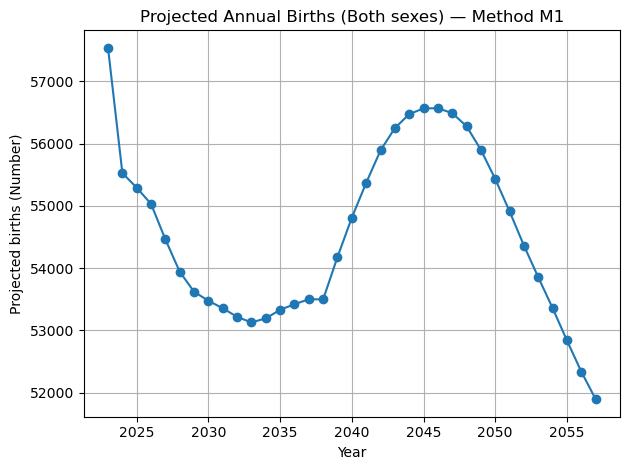

In [12]:
# Plotting function and call
def plot_projected_births(frame, labels, save_to=None):
    """
    Draws a single line chart of projected births by year.
    Set save_to="plot.png" to also save the figure.
    """
    plt.figure()
    plt.plot(frame["Year"], frame["ProjectedBirths"], marker="o")  # single plot, no colours specified
    plt.title(labels["title"])
    plt.xlabel(labels["x_label"])
    plt.ylabel(labels["y_label"])
    plt.grid(True)
    plt.tight_layout()
    if save_to:
        plt.savefig(save_to, dpi=150)
    plt.show()

# Using the function
plot_projected_births(df, label)
# plot_projected_births(df, label, save_to="projected_births.png")  # optional save


## End